# Repository Static Analysis with SonarQube

Clones a **GitHub repository**, scans it with a local SonarQube Community server, and reports
**code complexity** (cyclomatic + cognitive, per project and per file) and **issues**
(bugs, vulnerabilities, code smells).

Runs on Windows, macOS and Linux — the scanner binary is chosen automatically for your platform.

## Prerequisites
- **Docker Desktop** installed and *running* (this notebook starts the SonarQube container for you)
- **git** on your PATH
- **Java 17+** on your PATH (`java -version`)
- ~4 GB free RAM for the SonarQube container

Run the cells top to bottom. The first run takes a few minutes (image pull + server boot).

## 0. Dependencies

In [97]:
%pip install -q requests pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Configuration

Point `REPO_URL` at the GitHub repo you want to analyze. Everything else has a sane default.

In [ ]:
import os, re, sys, platform, pathlib

# ---- what to analyze -------------------------------------------------------
REPO_URL    = "https://github.com/ImgyeongLee/Aida-starter-template.git"
REPO_BRANCH = "r2-0901"     # None = the repo's default branch
CLONE_DEPTH = 1             # shallow clone; set to None for full history

# SonarQube Community Edition has NO branch support - every scan of a given
# project key overwrites the previous one. Keep this True to give each branch
# its own project, so branches can be compared side by side.
SEPARATE_PROJECT_PER_BRANCH = True

# ---- where things live -----------------------------------------------------
WORKSPACE    = pathlib.Path.cwd()
PROJECTS_DIR = WORKSPACE / "projects"
TOOLS_DIR    = WORKSPACE / ".tools"
TOKEN_FILE   = WORKSPACE / ".sonar-token"      # generated token is cached here

# ---- SonarQube server ------------------------------------------------------
SONAR_HOST      = "http://localhost:9000"
SONAR_IMAGE     = "sonarqube:community"
SONAR_CONTAINER = "sonarqube"
SONAR_ADMIN     = "admin"
SONAR_DEFAULT_PASSWORD = "admin"               # factory default
SONAR_NEW_PASSWORD     = "Analysis!2024"       # set on first boot (Sonar forces a change)

# ---- scanner ---------------------------------------------------------------
SCANNER_VERSION = "7.2.0.5079"
SCANNER_OPTS    = "-Xmx2048m"                  # raise if the scan OOMs on a big repo

# ---- what to skip ----------------------------------------------------------
# Repo-specific directories to leave out of the analysis, relative to the repo
# root. Add or remove entries here, then re-run from this cell.
EXCLUDE_DIRS = [
    "apps/extension",
]

# Generic build output / vendored code that should never be analyzed.
_BOILERPLATE_EXCLUSIONS = [
    "**/node_modules/**", "**/dist/**", "**/build/**", "**/out/**", "**/target/**",
    "**/vendor/**", "**/.venv/**", "**/venv/**", "**/__pycache__/**",
    "**/*.min.js", "**/*.min.css", "**/*.lock", "**/*-lock.json", "**/*.map",
]

EXCLUSIONS = ",".join(
    _BOILERPLATE_EXCLUSIONS + [f"{d.strip('/')}/**" for d in EXCLUDE_DIRS]
)

# ---- derived ---------------------------------------------------------------
REPO_NAME = re.sub(r"\.git$", "", REPO_URL.rstrip("/").split("/")[-1])
REPO_DIR  = PROJECTS_DIR / REPO_NAME

_key_base = REPO_NAME
if SEPARATE_PROJECT_PER_BRANCH and REPO_BRANCH:
    _key_base = f"{REPO_NAME}--{REPO_BRANCH}"

PROJECT_KEY  = re.sub(r"[^A-Za-z0-9_.\-]", "-", _key_base)
PROJECT_NAME = _key_base

PROJECTS_DIR.mkdir(exist_ok=True)
TOOLS_DIR.mkdir(exist_ok=True)

print(f"Repository : {REPO_URL}")
print(f"Branch     : {REPO_BRANCH or '(default)'}")
print(f"Clone path : {REPO_DIR}")
print(f"Project key: {PROJECT_KEY}")
print(f"Platform   : {platform.system()} / {platform.machine()}")
print("Excluding  :", ", ".join(EXCLUDE_DIRS) or "(nothing repo-specific)")


Repository : https://github.com/ImgyeongLee/Aida-starter-template.git
Branch     : r1-0901
Clone path : e:\RepositoryStaticAnalysis\projects\Aida-starter-template
Project key: Aida-starter-template--r1-0901
Platform   : Windows / AMD64
Excluding  : apps/extension


## 2. Sanity-check the toolchain

Fails loudly here rather than three cells later.

In [99]:
import shutil, subprocess

def _run(cmd, **kw):
    return subprocess.run(cmd, capture_output=True, text=True,
                          encoding="utf-8", errors="replace", **kw)

ok = True

for tool, probe in [("git", ["git", "--version"]),
                    ("java", ["java", "-version"]),
                    ("docker", ["docker", "--version"])]:
    if shutil.which(tool) is None:
        print(f"MISSING: {tool} is not on your PATH")
        ok = False
        continue
    r = _run(probe)
    print(f"OK  {tool:7s} {(r.stdout or r.stderr).splitlines()[0]}")

# the docker CLI existing does not mean the daemon is running
r = _run(["docker", "info", "--format", "{{.ServerVersion}}"])
if r.returncode != 0:
    print("\nDocker daemon is NOT running. Start Docker Desktop, wait for it, re-run this cell.")
    ok = False
else:
    print(f"OK  daemon  Docker engine {r.stdout.strip()}")

print("\nAll prerequisites satisfied." if ok else "\nFix the items above before continuing.")

OK  git     git version 2.45.2.windows.1
OK  java    openjdk version "17.0.16" 2025-07-15
OK  docker  Docker version 29.5.3, build d1c06ef
OK  daemon  Docker engine 29.5.3

All prerequisites satisfied.


## 3. Clone (or refresh) the repository

In [100]:
from collections import Counter

def git(*args):
    return _run(["git", "-C", str(REPO_DIR)] + list(args))

if not REPO_DIR.exists():
    cmd = ["git", "clone"]
    if CLONE_DEPTH:
        cmd += ["--depth", str(CLONE_DEPTH)]
    if REPO_BRANCH:
        cmd += ["--branch", REPO_BRANCH]
    cmd += [REPO_URL, str(REPO_DIR)]
    print("Cloning ...")
    r = _run(cmd)
    if r.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{r.stderr}")
    print(f"Cloned into {REPO_DIR}")
else:
    print(f"Already cloned: {REPO_DIR}")

# --- make the working tree actually match REPO_BRANCH -----------------------
# A --depth clone is single-branch, so widen the refspec before fetching or
# other branches will never be visible.
git("config", "remote.origin.fetch", "+refs/heads/*:refs/remotes/origin/*")

if REPO_BRANCH:
    r = git("fetch", "origin", REPO_BRANCH, "--quiet")
    if r.returncode != 0:
        raise RuntimeError(f"Could not fetch branch '{REPO_BRANCH}':\n{r.stderr}")

    # never clobber uncommitted work (.scannerwork is untracked, so it is ignored here)
    dirty = git("status", "--porcelain", "--untracked-files=no").stdout.strip()
    if dirty:
        raise RuntimeError(
            f"{REPO_DIR} has uncommitted changes - refusing to switch branches.\n"
            f"{dirty}\nCommit or discard them, then re-run this cell."
        )

    r = git("checkout", "-B", REPO_BRANCH, f"origin/{REPO_BRANCH}", "--quiet")
    if r.returncode != 0:
        raise RuntimeError(f"Could not check out '{REPO_BRANCH}':\n{r.stderr}")
else:
    git("fetch", "--all", "--quiet")

current = git("rev-parse", "--abbrev-ref", "HEAD").stdout.strip()
head    = git("log", "-1", "--format=%h %ad %s", "--date=short").stdout.strip()

# fail loudly rather than silently scanning the wrong code
if REPO_BRANCH and current != REPO_BRANCH:
    raise RuntimeError(f"Expected branch '{REPO_BRANCH}' but the tree is on '{current}'")

print(f"Branch : {current}")
print(f"HEAD   : {head}")

# quick language census, so you know what Sonar will actually see
counts = Counter()
for p in REPO_DIR.rglob("*"):
    parts = p.parts
    if p.is_file() and ".git" not in parts and "node_modules" not in parts and p.suffix:
        counts[p.suffix] += 1
print("\nTop file extensions:")
for ext, n in counts.most_common(10):
    print(f"  {ext:8s} {n}")


Already cloned: e:\RepositoryStaticAnalysis\projects\Aida-starter-template
Branch : r1-0901
HEAD   : ce31a3a 2026-09-01 completed: round 1 (Sep 1st)

Top file extensions:
  .ts      41
  .json    18
  .tsx     9
  .js      4
  .svg     4
  .md      2
  .yaml    2
  .sh      2
  .example 2
  .txt     1


## 4. Start the SonarQube server

Starts the container if it is not already up, then waits for the server to report `UP`.
A cold start pulls the image and takes 1-3 minutes.

In [101]:
import time, requests

def container_state(name):
    r = _run(["docker", "inspect", "-f", "{{.State.Status}}", name])
    return r.stdout.strip() if r.returncode == 0 else None

state = container_state(SONAR_CONTAINER)
if state is None:
    print(f"Creating container '{SONAR_CONTAINER}' from {SONAR_IMAGE} (may pull the image) ...")
    r = _run(["docker", "run", "-d", "--name", SONAR_CONTAINER, "-p", "9000:9000", SONAR_IMAGE])
    if r.returncode != 0:
        raise RuntimeError(f"docker run failed:\n{r.stderr}")
    print("Container created.")
elif state != "running":
    print(f"Container exists but is '{state}' - starting it ...")
    _run(["docker", "start", SONAR_CONTAINER])
else:
    print("Container already running.")

print("\nWaiting for SonarQube to come up (this is the slow part) ...")
deadline = time.time() + 420
status = None
while time.time() < deadline:
    try:
        status = requests.get(f"{SONAR_HOST}/api/system/status", timeout=5).json().get("status")
    except requests.RequestException:
        status = "STARTING (no response yet)"
    if status == "UP":
        break
    print(f"  ... {status}")
    time.sleep(10)

if status != "UP":
    print(f"\nServer did not reach UP within the timeout (last status: {status}).")
    print(f"Check the logs:  docker logs --tail 50 {SONAR_CONTAINER}")
else:
    v = requests.get(f"{SONAR_HOST}/api/server/version", timeout=10).text.strip()
    print(f"\nSonarQube is UP - version {v}")

Container already running.

Waiting for SonarQube to come up (this is the slow part) ...

SonarQube is UP - version 26.6.0.123539


## 5. Authenticate

SonarQube forces a password change away from the `admin/admin` default on first boot.
This cell handles that, then mints an analysis token and caches it in `.sonar-token`
so re-runs do not need to regenerate it.

In [102]:
TOKEN_NAME = "notebook-token"

def _api(method, path, auth, **kw):
    return requests.request(method, f"{SONAR_HOST}{path}", auth=auth, timeout=30, **kw)

# 1. find the working admin password: the rotated one if already set, else the factory default
admin_auth = None
for candidate in (SONAR_NEW_PASSWORD, SONAR_DEFAULT_PASSWORD):
    try:
        valid = _api("GET", "/api/authentication/validate",
                     (SONAR_ADMIN, candidate)).json().get("valid")
    except Exception:
        valid = False
    if valid:
        admin_auth = (SONAR_ADMIN, candidate)
        print(f"Authenticated as '{SONAR_ADMIN}'.")
        break

if admin_auth is None:
    raise RuntimeError(
        "Could not log in as admin with either the default or the configured password.\n"
        "If you changed it manually, set SONAR_NEW_PASSWORD in the config cell."
    )

# 2. rotate off the factory default if we are still on it
if admin_auth[1] == SONAR_DEFAULT_PASSWORD and SONAR_NEW_PASSWORD != SONAR_DEFAULT_PASSWORD:
    r = _api("POST", "/api/users/change_password", admin_auth,
             data={"login": SONAR_ADMIN,
                   "previousPassword": SONAR_DEFAULT_PASSWORD,
                   "password": SONAR_NEW_PASSWORD})
    if r.status_code in (200, 204):
        admin_auth = (SONAR_ADMIN, SONAR_NEW_PASSWORD)
        print("Rotated the default admin password.")
    else:
        print(f"Password change returned {r.status_code} - continuing with the current one.")

# 3. reuse a cached token, or mint a fresh one
SONAR_TOKEN = TOKEN_FILE.read_text().strip() if TOKEN_FILE.exists() else ""

token_ok = False
if SONAR_TOKEN:
    token_ok = _api("GET", "/api/authentication/validate",
                    (SONAR_TOKEN, "")).json().get("valid", False)

if token_ok:
    print(f"Reusing cached token from {TOKEN_FILE.name}")
else:
    _api("POST", "/api/user_tokens/revoke", admin_auth, data={"name": TOKEN_NAME})  # no-op if absent
    r = _api("POST", "/api/user_tokens/generate", admin_auth, data={"name": TOKEN_NAME})
    if r.status_code != 200:
        raise RuntimeError(f"Token generation failed ({r.status_code}): {r.text}")
    SONAR_TOKEN = r.json()["token"]
    TOKEN_FILE.write_text(SONAR_TOKEN)
    print(f"Generated a new analysis token, cached in {TOKEN_FILE.name}")

auth = (SONAR_TOKEN, "")   # token auth for every call from here on

Authenticated as 'admin'.
Reusing cached token from .sonar-token


## 6. Download the sonar-scanner CLI for this platform

In [103]:
import urllib.request, zipfile, stat

def scanner_platform():
    sysname, machine = platform.system(), platform.machine().lower()
    arm = machine in ("arm64", "aarch64")
    if sysname == "Windows":
        return "windows-x64", "sonar-scanner.bat"
    if sysname == "Darwin":
        return ("macosx-aarch64" if arm else "macosx-x64"), "sonar-scanner"
    if sysname == "Linux":
        return ("linux-aarch64" if arm else "linux-x64"), "sonar-scanner"
    raise RuntimeError(f"Unsupported platform: {sysname}/{machine}")

plat, binary_name = scanner_platform()
dist = f"sonar-scanner-{SCANNER_VERSION}-{plat}"
scanner_home = TOOLS_DIR / dist
SCANNER_BIN = scanner_home / "bin" / binary_name

if SCANNER_BIN.exists():
    print(f"Scanner already installed: {SCANNER_BIN}")
else:
    url = ("https://binaries.sonarsource.com/Distribution/sonar-scanner-cli/"
           f"sonar-scanner-cli-{SCANNER_VERSION}-{plat}.zip")
    zip_path = TOOLS_DIR / "scanner.zip"
    print(f"Downloading {url} ...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(TOOLS_DIR)
    zip_path.unlink()
    # the zip does not carry the exec bit on POSIX
    if platform.system() != "Windows":
        for f in (scanner_home / "bin").iterdir():
            f.chmod(f.stat().st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)
        jre = scanner_home / "jre" / "bin" / "java"
        if jre.exists():
            jre.chmod(jre.stat().st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)
    print(f"Installed: {SCANNER_BIN}")

if not SCANNER_BIN.exists():
    raise RuntimeError(f"Scanner binary not found at {SCANNER_BIN}")

Scanner already installed: e:\RepositoryStaticAnalysis\.tools\sonar-scanner-7.2.0.5079-windows-x64\bin\sonar-scanner.bat


## 7. Create the project on the server

In [104]:
r = _api("POST", "/api/projects/create", auth,
         data={"project": PROJECT_KEY, "name": PROJECT_NAME})

if r.status_code in (200, 204):
    print(f"Created project '{PROJECT_KEY}'.")
elif r.status_code == 400:
    msg = r.json().get("errors", [{}])[0].get("msg", "")
    print(f"Project '{PROJECT_KEY}' already exists - reusing it.  ({msg})")
else:
    raise RuntimeError(f"Unexpected response {r.status_code}: {r.text}")

Project 'Aida-starter-template--r1-0901' already exists - reusing it.  (Could not create Project with key: "Aida-starter-template--r1-0901". A similar key already exists: "Aida-starter-template--r1-0901")


## 8. Run the scan

Streams the scanner output, then **polls the server's background task** until the report is
actually ingested. (Sleeping a few seconds and hoping is the classic cause of
"my results are empty, or from the previous run".)

In [105]:
VERBOSE_SCAN = False   # True to see every INFO line

scan_env = dict(os.environ, SONAR_SCANNER_OPTS=SCANNER_OPTS)

cmd = [
    str(SCANNER_BIN),
    f"-Dsonar.projectKey={PROJECT_KEY}",
    f"-Dsonar.projectName={PROJECT_NAME}",
    "-Dsonar.sources=.",
    f"-Dsonar.projectBaseDir={REPO_DIR}",
    f"-Dsonar.host.url={SONAR_HOST}",
    f"-Dsonar.token={SONAR_TOKEN}",
    f"-Dsonar.exclusions={EXCLUSIONS}",
    "-Dsonar.sourceEncoding=UTF-8",
    "-Dsonar.scm.disabled=true",
]

print(f"Scanning {REPO_DIR} ...\n")
proc = subprocess.Popen(cmd, cwd=str(REPO_DIR), env=scan_env,
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        text=True, encoding="utf-8", errors="replace", bufsize=1)

KEEP = ("WARN", "ERROR", "EXECUTION", "ANALYSIS SUCCESSFUL", "indexed", "Load", "QUALITY")
tail = []
for line in proc.stdout:
    line = line.rstrip()
    tail.append(line)
    tail = tail[-60:]
    if VERBOSE_SCAN or any(k in line for k in KEEP):
        print(line)

rc = proc.wait()
if rc != 0:
    print("\n--- last 60 lines ---")
    print("\n".join(tail))
    raise RuntimeError(f"sonar-scanner exited with code {rc}")

print(f"\nScanner finished (exit {rc}).")

Scanning e:\RepositoryStaticAnalysis\projects\Aida-starter-template ...



18:17:45.237 INFO  Load global settings
18:17:45.309 INFO  Load global settings (done) | time=70ms
18:17:45.316 INFO  Loading required plugins
18:17:45.316 INFO  Load plugins index
18:17:45.327 INFO  Load plugins index (done) | time=10ms
18:17:45.327 INFO  Load/download plugins
18:17:45.351 INFO  Load/download plugins (done) | time=24ms
18:17:45.571 INFO  Load project settings for component key: 'Aida-starter-template--r1-0901'
18:17:45.581 INFO  Load project settings for component key: 'Aida-starter-template--r1-0901' (done) | time=9ms
18:17:45.595 INFO  Load quality profiles
18:17:45.626 INFO  Load quality profiles (done) | time=31ms
18:17:45.646 INFO  Load active rules
18:17:45.870 INFO  Load active rules (done) | time=223ms
18:17:45.871 INFO  Load analysis cache
18:17:45.898 INFO  Load analysis cache | time=27ms
18:17:46.160 INFO  Loading plugins for detected languages
18:17:46.160 INFO  Load/download plugins
18:17:46.165 INFO  Load/download plugins (done) | time=5ms
18:17:46.335 I

In [106]:
# Wait for the server to finish processing the submitted report.
task_file = REPO_DIR / ".scannerwork" / "report-task.txt"
if not task_file.exists():
    raise RuntimeError(f"{task_file} not found - the scan did not submit a report.")

meta = dict(l.split("=", 1) for l in task_file.read_text().strip().splitlines() if "=" in l)
task_id = meta["ceTaskId"]
print(f"Background task {task_id} - waiting for ingestion ...")

deadline = time.time() + 300
task_status = None
while time.time() < deadline:
    task = _api("GET", "/api/ce/task", auth, params={"id": task_id}).json().get("task", {})
    task_status = task.get("status")
    if task_status in ("SUCCESS", "FAILED", "CANCELED"):
        break
    time.sleep(3)

print(f"Task status: {task_status}")
if task_status != "SUCCESS":
    raise RuntimeError(f"Report processing did not succeed (status={task_status}). See "
                       f"{SONAR_HOST}/project/background_tasks?id={PROJECT_KEY}")
print("Analysis is live on the server.")

Background task 4e9812a7-771f-4847-ac02-6d3f28b2d299 - waiting for ingestion ...
Task status: SUCCESS
Analysis is live on the server.


## 9. Issues

Bugs, vulnerabilities and code smells from the latest analysis.

In [107]:
import pandas as pd

def fetch_issues(project_key, page_size=500):
    issues, page = [], 1
    while True:
        r = _api("GET", "/api/issues/search", auth, params={
            "componentKeys": project_key, "ps": page_size, "p": page, "resolved": "false",
        })
        r.raise_for_status()
        data = r.json()
        batch = data.get("issues", [])
        issues.extend(batch)
        total = data.get("total", 0)
        # SonarQube refuses to page past 10 000 results
        if not batch or len(issues) >= total or page * page_size >= 10000:
            break
        page += 1
    return issues

raw_issues = fetch_issues(PROJECT_KEY)
print(f"Open issues: {len(raw_issues)}")

rows = []
for issue in raw_issues:
    # SonarQube 10+ reports "impacts"; older versions only "severity"/"type"
    impacts = issue.get("impacts") or []
    rows.append({
        "severity": issue.get("severity") or (impacts[0]["severity"] if impacts else None),
        "type":     issue.get("type") or (impacts[0]["softwareQuality"] if impacts else None),
        "file":     issue.get("component", "").split(":", 1)[-1],
        "line":     issue.get("textRange", {}).get("startLine"),
        "rule":     issue.get("rule"),
        "effort":   issue.get("effort"),
        "message":  issue.get("message"),
    })

issues_df = pd.DataFrame(rows)

if issues_df.empty:
    print("No open issues found.")
else:
    issues_df["line"] = pd.to_numeric(issues_df["line"], errors="coerce").astype("Int64")
    sev_order = ["BLOCKER", "CRITICAL", "HIGH", "MAJOR", "MEDIUM", "MINOR", "LOW", "INFO"]
    present = [s for s in sev_order if s in set(issues_df["severity"])]
    issues_df["severity"] = pd.Categorical(issues_df["severity"], categories=present, ordered=True)
    issues_df = issues_df.sort_values(["severity", "file", "line"]).reset_index(drop=True)

    pd.set_option("display.max_colwidth", 70)
    pd.set_option("display.max_rows", 200)
    display(issues_df)

Open issues: 20


,severity,type,file,line,rule,effort,message
0,CRITICAL,CODE_SMELL,apps/api/src/llm.ts,16,typescript:S3776,6min,Refactor this function to reduce its Cognitive Complexity from 16 ...
1,CRITICAL,CODE_SMELL,apps/web/src/App.tsx,27,typescript:S3735,5min,"Remove this use of the ""void"" operator."
2,MAJOR,CODE_SMELL,apps/web/src/components/AuthScreen.tsx,56,typescript:S6772,5min,Ambiguous spacing before next element input
3,MAJOR,CODE_SMELL,apps/web/src/components/AuthScreen.tsx,67,typescript:S6772,5min,Ambiguous spacing before next element input
4,MAJOR,CODE_SMELL,apps/web/src/components/AuthScreen.tsx,85,typescript:S3358,5min,Extract this nested ternary operation into an independent statement.
5,MAJOR,CODE_SMELL,apps/web/src/components/MarkdownMessage.tsx,6,typescript:S6850,5min,Headings must have content and the content must be accessible by a...
6,MAJOR,CODE_SMELL,apps/web/src/components/MarkdownMessage.tsx,7,typescript:S6850,5min,Headings must have content and the content must be accessible by a...
7,MAJOR,CODE_SMELL,apps/web/src/components/MarkdownMessage.tsx,8,typescript:S6850,5min,Headings must have content and the content must be accessible by a...
8,MINOR,VULNERABILITY,apps/api/src/index.ts,7,typescript:S5689,5min,This framework implicitly discloses version information by default...
9,MINOR,CODE_SMELL,apps/web/src/components/ChatWindow.tsx,14,typescript:S6759,5min,Mark the props of the component as read-only.


## 10. Issue summary

In [108]:
if not issues_df.empty:
    print("=== By severity ===")
    display(issues_df.groupby("severity", observed=True).size().rename("count").reset_index())

    print("=== By type ===")
    display(issues_df.groupby("type", observed=True).size().rename("count").reset_index())

    print("=== Top 10 rules ===")
    top_rules = issues_df["rule"].value_counts().head(10).reset_index()
    top_rules.columns = ["rule", "count"]
    display(top_rules)

    print("=== Top 10 files by issue count ===")
    top_files = issues_df["file"].value_counts().head(10).reset_index()
    top_files.columns = ["file", "count"]
    display(top_files)

=== By severity ===


,severity,count
0,CRITICAL,2
1,MAJOR,6
2,MINOR,12


=== By type ===


,type,count
0,CODE_SMELL,19
1,VULNERABILITY,1


=== Top 10 rules ===


,rule,count
0,typescript:S7764,6
1,typescript:S6759,5
2,typescript:S6850,3
3,typescript:S6772,2
4,typescript:S3358,1
5,typescript:S3735,1
6,typescript:S3776,1
7,typescript:S5689,1


=== Top 10 files by issue count ===


,file,count
0,apps/web/src/instrumentation.ts,5
1,apps/web/src/components/MarkdownMessage.tsx,4
2,apps/web/src/components/AuthScreen.tsx,3
3,apps/web/src/components/Sidebar.tsx,2
4,apps/web/src/App.tsx,1
5,apps/api/src/llm.ts,1
6,apps/web/src/components/ChatWindow.tsx,1
7,apps/api/src/index.ts,1
8,apps/web/src/components/MessageComposer.tsx,1
9,apps/web/src/hooks/useAuth.tsx,1


## 11. Project-level metrics, including complexity

In [109]:
METRICS = [
    # size
    "ncloc", "files", "functions", "classes", "statements", "comment_lines_density",
    # complexity
    "complexity", "cognitive_complexity",
    # issues
    "bugs", "vulnerabilities", "code_smells", "security_hotspots",
    # ratings and debt
    "reliability_rating", "security_rating", "sqale_rating", "sqale_index",
    "duplicated_lines_density", "coverage",
]

r = _api("GET", "/api/measures/component", auth,
         params={"component": PROJECT_KEY, "metricKeys": ",".join(METRICS)})
r.raise_for_status()
measures = {m["metric"]: m.get("value")
            for m in r.json().get("component", {}).get("measures", [])}

RATING = {"1.0": "A", "2.0": "B", "3.0": "C", "4.0": "D", "5.0": "E"}

def pretty(metric, value):
    if value is None:
        return "n/a"
    if metric.endswith("_rating"):
        return RATING.get(value, value)
    if metric == "sqale_index":
        mins = int(value)
        return f"{mins // 480}d {(mins % 480) // 60}h {mins % 60}m"
    if metric.endswith("_density") or metric == "coverage":
        return f"{value}%"
    return value

metrics_df = pd.DataFrame([{"metric": m, "value": pretty(m, measures.get(m))} for m in METRICS])
display(metrics_df)

if measures.get("complexity") and measures.get("functions"):
    per_fn = float(measures["complexity"]) / max(float(measures["functions"]), 1)
    print(f"\nCyclomatic complexity per function: {per_fn:.2f}")
if measures.get("complexity") and measures.get("ncloc"):
    per_loc = 100 * float(measures["complexity"]) / max(float(measures["ncloc"]), 1)
    print(f"Cyclomatic complexity per 100 LOC : {per_loc:.2f}")

,metric,value
0,ncloc,1605
1,files,36
2,functions,136
3,classes,1
4,statements,555
5,comment_lines_density,3.4%
6,complexity,270
7,cognitive_complexity,140
8,bugs,0
9,vulnerabilities,1



Cyclomatic complexity per function: 1.99
Cyclomatic complexity per 100 LOC : 16.82


## 12. Per-file complexity

The hotspot list - which files actually carry the complexity.

In [110]:
def fetch_file_measures(project_key, metric_keys, page_size=500):
    out, page = [], 1
    while True:
        r = _api("GET", "/api/measures/component_tree", auth, params={
            "component": project_key, "metricKeys": ",".join(metric_keys),
            "qualifiers": "FIL", "ps": page_size, "p": page,
        })
        r.raise_for_status()
        data = r.json()
        out.extend(data.get("components", []))
        total = data.get("paging", {}).get("total", 0)
        if page * page_size >= total:
            break
        page += 1
    return out

file_metrics = ["complexity", "cognitive_complexity", "ncloc", "functions",
                "code_smells", "bugs", "vulnerabilities"]
components = fetch_file_measures(PROJECT_KEY, file_metrics)

rows = []
for c in components:
    row = {"file": c.get("path", c.get("key"))}
    vals = {m["metric"]: m.get("value") for m in c.get("measures", [])}
    for m in file_metrics:
        row[m] = pd.to_numeric(vals.get(m), errors="coerce")
    rows.append(row)

files_df = pd.DataFrame(rows)

if files_df.empty:
    print("No per-file measures returned.")
else:
    files_df = files_df.fillna(0)
    for m in file_metrics:
        files_df[m] = files_df[m].astype(int)
    files_df["complexity_per_loc"] = (
        files_df["complexity"] / files_df["ncloc"].replace(0, pd.NA)
    ).round(3)
    files_df = files_df.sort_values("cognitive_complexity", ascending=False).reset_index(drop=True)

    print(f"{len(files_df)} files analyzed\n")
    print("=== Most complex files (by cognitive complexity) ===")
    display(files_df.head(20))

    # --- per-file distribution -------------------------------------------
    summary_metrics = file_metrics + ["complexity_per_loc"]
    stats_df = pd.DataFrame({
        "metric": summary_metrics,
        "mean":   [pd.to_numeric(files_df[m], errors="coerce").mean().round(2)
                   for m in summary_metrics],
        "median": [pd.to_numeric(files_df[m], errors="coerce").median().round(2)
                   for m in summary_metrics],
    })

    print("\n=== Per-file distribution across {} files ===".format(len(files_df)))
    display(stats_df)


36 files analyzed

=== Most complex files (by cognitive complexity) ===


,file,complexity,cognitive_complexity,ncloc,functions,code_smells,bugs,vulnerabilities,complexity_per_loc
0,apps/web/src/components/ChatWindow.tsx,36,27,151,18,1,0,0,0.238
1,apps/web/src/lib/chatStream.ts,21,18,73,3,0,0,0,0.288
2,apps/api/src/llm.ts,11,16,40,1,1,0,0,0.275
3,apps/web/src/instrumentation.ts,33,14,130,13,5,0,0,0.254
4,apps/web/src/components/AuthScreen.tsx,15,12,88,6,3,0,0,0.170
5,apps/api/src/routes/conversations.ts,27,11,158,15,0,0,0,0.171
6,apps/web/src/components/Sidebar.tsx,22,9,98,13,2,0,0,0.224
7,apps/web/src/hooks/useAuth.tsx,14,8,60,10,1,0,0,0.233
8,apps/api/src/auth.ts,14,6,81,7,0,0,0,0.173
9,apps/api/src/routes/auth.ts,12,5,68,4,0,0,0,0.176



=== Per-file distribution across 36 files ===


,metric,mean,median
0,complexity,7.50,3.50
1,cognitive_complexity,3.89,0.00
2,ncloc,44.58,27.50
3,functions,3.78,1.50
4,code_smells,0.53,0.00
5,bugs,0.00,0.00
6,vulnerabilities,0.03,0.00
7,complexity_per_loc,0.14,0.16


## 13. Charts

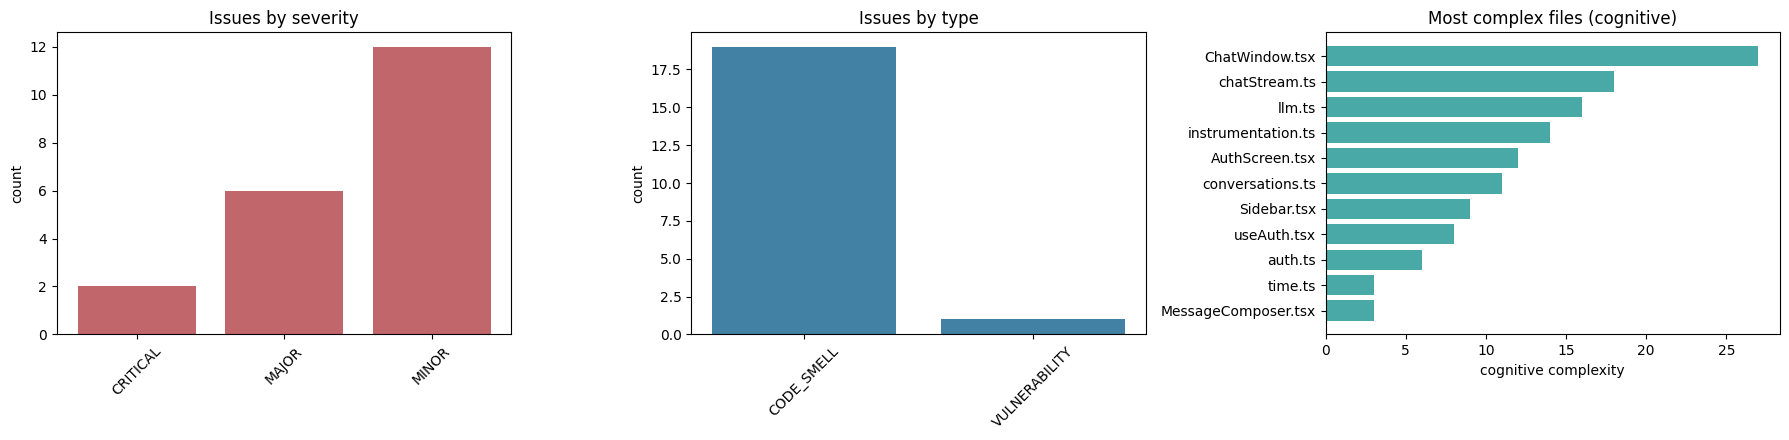

In [111]:
import matplotlib.pyplot as plt

have_issues = not issues_df.empty
have_files  = not files_df.empty

n = int(have_issues) * 2 + int(have_files)
if n == 0:
    print("Nothing to plot.")
else:
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4.5))
    axes = list(axes) if n > 1 else [axes]
    i = 0

    if have_issues:
        s = issues_df.groupby("severity", observed=True).size()
        axes[i].bar(s.index.astype(str), s.values, color="#c1666b")
        axes[i].set_title("Issues by severity")
        axes[i].set_ylabel("count")
        axes[i].tick_params(axis="x", rotation=45)
        i += 1

        t = issues_df.groupby("type", observed=True).size()
        axes[i].bar(t.index.astype(str), t.values, color="#4281a4")
        axes[i].set_title("Issues by type")
        axes[i].set_ylabel("count")
        axes[i].tick_params(axis="x", rotation=45)
        i += 1

    if have_files:
        top = files_df.head(12).iloc[::-1]
        labels = [str(f).replace("\\", "/").split("/")[-1] for f in top["file"]]
        axes[i].barh(labels, top["cognitive_complexity"], color="#48a9a6")
        axes[i].set_title("Most complex files (cognitive)")
        axes[i].set_xlabel("cognitive complexity")

    plt.tight_layout()
    plt.show()

## 14. Open the dashboard

In [112]:
url = f"{SONAR_HOST}/dashboard?id={PROJECT_KEY}"
print(f"Dashboard: {url}")
print(f"Login: {SONAR_ADMIN} / {SONAR_NEW_PASSWORD}")

import webbrowser
webbrowser.open(url)

Dashboard: http://localhost:9000/dashboard?id=Aida-starter-template--r1-0901
Login: admin / Analysis!2024


True

---
### Analyzing another repository

Change `REPO_URL` in the config cell and re-run from cell 1. Each repo gets its own
project key, so results do not overwrite each other.

### Cleanup

```
docker stop sonarqube      # pause the server; `docker start sonarqube` resumes it
docker rm -f sonarqube     # remove it entirely (deletes all analysis history)
```